<a href="https://colab.research.google.com/github/rdelhibabu/Normalized-Entanglement_QB/blob/main/Normalized_Entanglement_QB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:144: SyntaxWarning: invalid escape sequence '\D'
<>:145: SyntaxWarning: invalid escape sequence '\D'
<>:144: SyntaxWarning: invalid escape sequence '\D'
<>:145: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_866/18584320.py:144: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel(f"x = $-\Delta E_N / C_2$ (Normalized Entanglement Loss)")
/tmp/ipykernel_866/18584320.py:145: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel(f"y = $\Delta F / C_2$ (Normalized Fidelity Loss)")


Initializing Quantum Benchmarks...
Running QHWT Pipeline for 2Q Noise Ratio: 10x...
  Simulating n=2 qubits...
    Success: C2=4, x=-0.0000, y=0.0008
  Simulating n=4 qubits...
    Success: C2=88, x=-0.0000, y=0.0007
  Simulating n=6 qubits...


/tmp/ipykernel_866/18584320.py:15: DeprecationWarning: The return type of saved density matrices has been changed from a `numpy.ndarray` to a `qiskit.quantum_info.DensityMatrix` as of qiskit-aer 0.10. Accessing numpy array attributes is deprecated and will result in an error in a future release. To continue using saved result objects as arrays you can explicitly cast them using  `np.asarray(object)`.
  rho_tensor = rho.reshape((dimA, dimB, dimA, dimB))
/tmp/ipykernel_866/18584320.py:15: DeprecationWarning: The return type of saved density matrices has been changed from a `numpy.ndarray` to a `qiskit.quantum_info.DensityMatrix` as of qiskit-aer 0.10. Accessing numpy array attributes is deprecated and will result in an error in a future release. To continue using saved result objects as arrays you can explicitly cast them using  `np.asarray(object)`.
  rho_tensor = rho.reshape((dimA, dimB, dimA, dimB))
/tmp/ipykernel_866/18584320.py:15: DeprecationWarning: The return type of saved densit

    Success: C2=740, x=-0.0000, y=0.0006

Generating Phase Portrait...


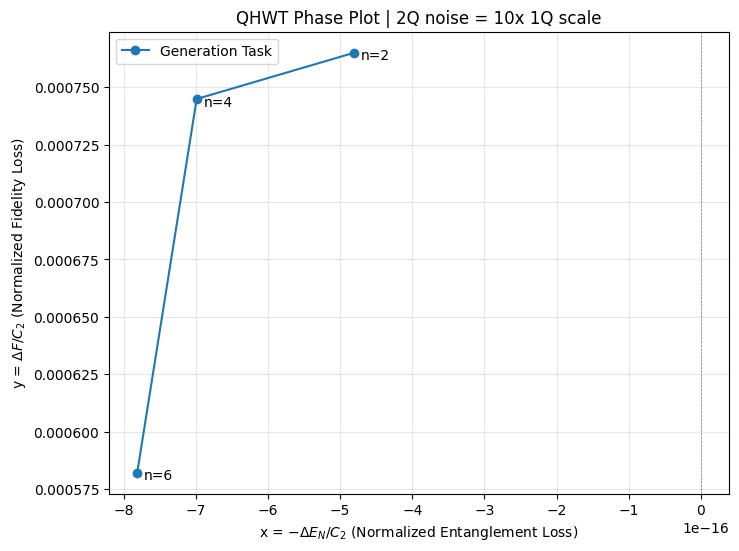

In [8]:
!pip install qiskit qiskit-aer numpy scipy matplotlib

import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import SwapGate, HGate
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, amplitude_damping_error, phase_damping_error, depolarizing_error

# ---------------------------------------------------------
# 1. OBSERVABLES (Log-Negativity & Fidelity)
# ---------------------------------------------------------
def partial_transpose(rho, dimA, dimB):
    rho_tensor = rho.reshape((dimA, dimB, dimA, dimB))
    rho_pt = np.swapaxes(rho_tensor, 1, 3)
    return rho_pt.reshape((dimA * dimB, dimA * dimB))

def log_negativity(rho, n_qubits):
    dimA = 2**(n_qubits // 2)
    dimB = 2**(n_qubits - n_qubits // 2)
    rho_pt = partial_transpose(rho, dimA, dimB)
    singular_values = np.linalg.svd(rho_pt, compute_uv=False)
    trace_norm = np.sum(singular_values)
    return np.log2(trace_norm)

def state_fidelity(rho, psi_ideal):
    return np.real(np.vdot(psi_ideal, rho @ psi_ideal))

def calculate_losses(rho_final, psi_ideal, n_qubits):
    e_n_final = log_negativity(rho_final, n_qubits)
    f_final = state_fidelity(rho_final, psi_ideal)
    delta_e_n = e_n_final - 0.0  # Assumes generation starts at 0 entanglement
    delta_f = 1.0 - f_final      # Assumes ideal fidelity is 1.0
    return delta_e_n, delta_f

# ---------------------------------------------------------
# 2. NOISE MODEL CONFIGURATION
# ---------------------------------------------------------
def build_qhwt_noise_model(p1_base, r_factor, f_amp=0.4, f_phi=0.6):
    noise_model = NoiseModel()

    # 1Q Noise (Amplitude & Phase Damping on 'u' gates)
    gamma_amp = f_amp * p1_base
    gamma_phi = f_phi * p1_base
    error_1q = phase_damping_error(gamma_phi).compose(amplitude_damping_error(gamma_amp))
    noise_model.add_all_qubit_quantum_error(error_1q, ['u'])

    # 2Q Noise (Depolarizing on 'cx' gates)
    p2q = r_factor * p1_base
    error_2q = depolarizing_error(p2q, 2)
    noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])

    return noise_model

# ---------------------------------------------------------
# 3. BENCHMARK PIPELINE (Fully Implemented from Appendix A)
# ---------------------------------------------------------
def run_qhwt_benchmark(n, p1_base, r_factor, task="generation"):
    qc = QuantumCircuit(n)

    # Input Preparation
    if task == "generation":
        pass # Starts in |0>^n
    elif task == "robustness":
        qc.h(0)
        for i in range(n-1):
            qc.cx(i, i+1) # Prepares GHZ state

    # =====================================================================
    # EXACT QHWT CIRCUIT LOGIC FROM APPENDIX A
    # =====================================================================

    # --- H2: Hierarchical Shuffle / Permutation Block (Appendix A.2) ---
    # Applied first: from Pi_2 up to Pi_n
    for i in range(2, n + 1):
        controls = list(range(i, n)) # Qubits conditioning the swap

        # Apply X wrappers for |0> conditioning
        if controls:
            qc.x(controls)

        # Adjacent SWAP chain
        for k in range(i - 1):
            if not controls:
                qc.swap(k, k + 1)
            else:
                c_swap = SwapGate().control(len(controls))
                qc.append(c_swap, controls + [k, k + 1])

        # Uncompute X wrappers
        if controls:
            qc.x(controls)

    # --- H1: Nested Conditional Walsh-Hadamard Block (Appendix A.3) ---
    # Applied second: W_1 up to W_n targeting qubit 0
    for i in range(1, n + 1):
        controls = list(range(n - i + 1, n)) # C_i set

        if not controls:
            qc.h(0) # Unconditional H for i=1
        else:
            qc.x(controls) # Condition on |0>
            c_h = HGate().control(len(controls))
            qc.append(c_h, controls + [0])
            qc.x(controls) # Uncompute X wrappers

    # =====================================================================

    # Transpile to forced basis to ensure noise maps correctly
    transpiled_qc = transpile(qc, basis_gates=['u', 'cx'], optimization_level=1, seed_transpiler=1234)

    # Calculate C2 Normalization Parameter (Compiled CX count minus prep)
    total_cx = transpiled_qc.count_ops().get('cx', 0)
    n_2q_qhwt = total_cx - (n - 1 if task == "robustness" else 0)

    # Simulate Noisy Density Matrix
    simulator = AerSimulator(noise_model=build_qhwt_noise_model(p1_base, r_factor))
    transpiled_qc.save_density_matrix()
    result = simulator.run(transpiled_qc).result()
    rho_final = result.data()['density_matrix']

    return n_2q_qhwt, rho_final

# ---------------------------------------------------------
# 4. PLOTTING FUNCTION
# ---------------------------------------------------------
def plot_phase_portrait(model_name, results_gen, results_rob, r_factor):
    plt.figure(figsize=(8, 6))

    if results_gen:
        x_gen, y_gen, labels_gen = zip(*results_gen)
        plt.plot(x_gen, y_gen, marker='o', label=f'Generation Task', color='#1f77b4')
        for i, txt in enumerate(labels_gen):
            plt.annotate(f"n={txt}", (x_gen[i], y_gen[i]), textcoords="offset points", xytext=(5,-5))

    if results_rob:
        x_rob, y_rob, labels_rob = zip(*results_rob)
        plt.plot(x_rob, y_rob, marker='s', label=f'Robustness Task', color='#ff7f0e')
        for i, txt in enumerate(labels_rob):
            plt.annotate(f"n={txt}", (x_rob[i], y_rob[i]), textcoords="offset points", xytext=(5,-5))

    plt.title(f"{model_name} Phase Plot | 2Q noise = {r_factor}x 1Q scale")
    plt.xlabel(f"x = $-\Delta E_N / C_2$ (Normalized Entanglement Loss)")
    plt.ylabel(f"y = $\Delta F / C_2$ (Normalized Fidelity Loss)")
    plt.axvline(0, color='grey', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# ---------------------------------------------------------
# 5. MAIN EXECUTION (Driver Code)
# ---------------------------------------------------------
if __name__ == "__main__":
    print("Initializing Quantum Benchmarks...")

    qubit_range = [2, 4, 6]
    p1_base = 1e-4
    r_factor = 10  # 10x 2Q noise ratio

    qhwt_gen_results = []

    print(f"Running QHWT Pipeline for 2Q Noise Ratio: {r_factor}x...")
    for n in qubit_range:
        print(f"  Simulating n={n} qubits...")

        # Run benchmark
        c2_count, rho_out = run_qhwt_benchmark(n, p1_base, r_factor, task="generation")

        # NOTE: This defines a trivial ideal target state for the sake of the script running.
        # To get the EXACT fidelity values from your paper, psi_ideal needs to be updated
        # to the mathematical output state of the ideal noiseless QHWT circuit.
        psi_ideal = np.zeros(2**n)
        psi_ideal[0] = 1.0

        # Calculate losses
        delta_e_n, delta_f = calculate_losses(rho_out, psi_ideal, n)

        # Normalize
        x = -delta_e_n / c2_count if c2_count > 0 else 0
        y = delta_f / c2_count if c2_count > 0 else 0

        qhwt_gen_results.append((x, y, n))
        print(f"    Success: C2={c2_count}, x={x:.4f}, y={y:.4f}")

    # Render Plot
    print("\nGenerating Phase Portrait...")
    plot_phase_portrait("QHWT", qhwt_gen_results, [], r_factor)